                        Phase 5 of Project

In [16]:
from __future__ import annotations

import os, json, operator, webbrowser
from typing import Annotated, TypedDict, Literal
from datetime import date, time

import requests, psutil, wikipedia, winshell

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, BaseMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver


state that passes from node to node

In [17]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    tool_calls: Annotated[list[str], operator.add]
    memory: dict
    scratchpad: str


This Block lets the text to speak

In [18]:
import os
import time
import tempfile
from gtts import gTTS
import playsound

def speak(text, lang="ur"):
    # Create a real temp filename, then CLOSE the OS handle (Windows needs this!)
    fd, path = tempfile.mkstemp(suffix=".mp3")
    os.close(fd)

    try:
        # Save TTS to the temp file
        tts = gTTS(text=text, lang=lang, slow=False)
        tts.save(path)  # path must be a STRING

        # Play (blocks until finished)
        playsound.playsound(path)

    finally:
        # Retry deletion a few times in case Windows still holds a lock briefly
        for _ in range(10):
            try:
                os.remove(path)
                break
            except PermissionError:
                time.sleep(0.2)  # tiny delay then try again
            except FileNotFoundError:
                break

In [19]:
from dotenv import load_dotenv
load_dotenv()


NEWSAPI_API_KEY = os.getenv('News_API_KEY', 'YOUR_NEWSAPI_KEY')
OPENWEATHER_API_KEY = os.getenv('Weather_API_KEY', 'YOUR_OPENWEATHER_KEY')



Tools Defining

In [20]:

# @tool(name='cpu_monitor', description='Report CPU and memory utilization in percent.')
@tool
def cpu_monitor_tool(_: str='') -> str:
    
    """ Report CPU and memory utilization in percent. """

    cpu = psutil.cpu_percent(interval=0.7)
    mem = psutil.virtual_memory().percent
    return f'CPU usage: {cpu:.1f}%, Memory usage: {mem:.1f}%.'

# @tool(name='safe_delete', description='Delete a file under sandbox. Input is relative path under jarvis_sandbox.')
@tool
def empty_recyclebin_tool():

    """ Empties the Recycle Bin using winshell"""
    confirm = input(f"⚠️ Are you sure you want to Empty Recycle Bin? (y/n): ")
    if confirm.lower() == "y":
        try:
            winshell.recycle_bin().open()
            winshell.recycle_bin().empty(confirm=False, show_progress=False, sound=False)
            print("Recycle Bin Emptied Successfully.")
            speak("Recycle Bin Emptied Successfully")
        except Exception as e:
            print(f"An error occurred: {e}")
    else:
        return "Deletion cancelled."


#@tool(name='news_tool', description='Top headlines via NewsAPI for a country code (us, gb, pk, etc.).')
@tool
def news_tool_tool(country_code: str='us') -> str:

    """ Top headlines via NewsAPI for a country code (us, gb, pk, etc.). """

    if not NEWSAPI_API_KEY or NEWSAPI_API_KEY=='YOUR_NEWSAPI_KEY':
        return 'NewsAPI key missing. Set NEWSAPI_API_KEY.'
    try:
        url = 'https://newsapi.org/v2/top-headlines'
        params = {'country': country_code, 'apiKey': NEWSAPI_API_KEY, 'pageSize': 5}
        data = requests.get(url, params=params, timeout=10).json()
        if data.get('status')!='ok':
            return f'NewsAPI error: {data}'
        titles = [a['title'] for a in data.get('articles', [])]
        return 'Top headlines:\n- ' + '\n- '.join(titles) if titles else 'No headlines.'
    except Exception as e:
        return f'News fetch failed: {e}'

#@tool(name='weather_tool', description='Current weather for a city using OpenWeather (metric).')
@tool
def weather_tool_tool(city: str='Karachi') -> str:

    """Current weather for a city using OpenWeather (metric)."""

    if not OPENWEATHER_API_KEY or OPENWEATHER_API_KEY=='YOUR_OPENWEATHER_KEY':
        return 'OpenWeather key missing. Set OPENWEATHER_API_KEY.'
    try:
        url = 'https://api.openweathermap.org/data/2.5/weather'
        params = {'q': city, 'appid': OPENWEATHER_API_KEY, 'units': 'metric'}
        data = requests.get(url, params=params, timeout=10).json()
        if 'main' not in data:
            return f'Weather error: {data.get('"message"', data)}'
        temp = data['main']['temp']; desc = data['weather'][0]['description']
        return f'Weather in {city}: {temp}°C, {desc}.'
    except Exception as e:
        return f'Weather fetch failed: {e}'

@tool
def date_time_tool():
    
    """ For Time and date as output using datetime"""

    current_date = date.now()
    current_time = time.now()
    return f"Time Right now is {current_time} and Date is {current_date}"

#@tool(name='wiki_tool', description='Short summary from Wikipedia for a topic (2 sentences).')
@tool
def wiki_tool_tool(topic: str) -> str:

    """Short summary from Wikipedia for a topic (2 sentences)."""

    try:
        wikipedia.set_lang('en')
        return wikipedia.summary(topic, sentences=2, auto_suggest=True, redirect=True)
    except Exception as e:
        return f'Wikipedia error: {e}'

@tool
def open_website(site_to_open):
    """open asked website using webbrowser"""
    print(f"{site_to_open} is Opened")
    url = f"https://{site_to_open}.com"  
    print(url)
    webbrowser.open(url)

@tool
def play_music(song):
    """play song using webbrowser on Youtube """
    # Stub: Replace with your music dict
    speak(f"Playing {song}")
    webbrowser.open("https://youtube.com/results?search_query=" + song)


LLM Call and System Prompt

In [21]:
MODEL_NAME = 'gpt-4o-mini'
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', 'YOUR_OPENAI_API_KEY')

llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
SYSTEM_ROUTER = SystemMessage(content=(
    
    'You are Bitty\'s routing brain. '
    'Available tools: cpu_monitor, safe_delete, news_tool, weather_tool, wiki_tool.\n'
    'Return ONLY JSON: {"action": "answer" | "tool:<name>", "argument": "..."}. '
    'Ask a brief clarifying question in answer mode if info is missing.'
))

This Block Decides which Tool to Call

In [22]:
def llm_router(state: AgentState) -> AgentState:
    convo = [SYSTEM_ROUTER] + state['messages']
    resp = llm.invoke(convo)
    action, argument = 'answer', ''
    try:
        data = json.loads(resp.content.strip())
        action = data.get('action','answer')
        argument = data.get('argument','')
    except Exception:
        return {'messages':[AIMessage(content=resp.content)], 'tool_calls':[], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}
    note = f'ROUTER DECISION -> action={action}, argument={argument}'
    return {'messages':[AIMessage(content=note)], 'tool_calls':[action], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}

This Block Dispatches the tool

In [23]:
TOOLS_BY_NAME = {
    'cpu_monitor': cpu_monitor_tool,
    'empty_tool': empty_recyclebin_tool,
    'news_tool': news_tool_tool,
    'weather_tool': weather_tool_tool,
    'datetime_tool' : date_time_tool, 
    'wiki_tool': wiki_tool_tool,
    'open_website_tool': open_website,
    'playmusic_tool': play_music
}

def tool_dispatcher(state: AgentState) -> AgentState:

    if not state.get('tool_calls'):
        return {'messages':[], 'tool_calls':[], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}
    
    decision = state['tool_calls'][-1]

    if not decision.startswith('tool:'):
        return {'messages':[], 'tool_calls':[], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}
    
    tool_name = decision.split('tool:',1)[-1].strip()
    
    tool_fn = TOOLS_BY_NAME.get(tool_name)
    
    argument = ''
    
    last_ai = state['messages'][-1].content if state.get('messages') else ''
    
    if 'argument=' in last_ai:
        argument = last_ai.split('argument=',1)[-1]
    
    if not tool_fn:
        return {'messages':[AIMessage(content=f'Unknown tool: {tool_name}')], 'tool_calls':[], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}
    
    try:
        result = tool_fn.invoke(argument) if hasattr(tool_fn, 'invoke') else tool_fn(argument)
    
    except Exception as e:
        result = f'Tool `{tool_name}` failed: {e}'
    
    return {'messages':[AIMessage(content=f'[{tool_name}]: {result}')], 'tool_calls':[], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}


This Block Passes the final output

In [24]:
def final_answer(state: AgentState) -> AgentState:
    last_assistant = None
    for msg in reversed(state['messages']):
        if isinstance(msg, AIMessage):
            last_assistant = msg; break
    content = last_assistant.content if last_assistant else 'Done.'
    return {'messages':[AIMessage(content=content)], 'tool_calls':[], 'memory':state.get('memory',{}), 'scratchpad':state.get('scratchpad','')}


Graph Building

In [25]:
def route_decision(state: AgentState) -> Literal['to_tool','to_answer']:
    if not state.get('tool_calls'):
        return 'to_answer'
    return 'to_tool' if state['tool_calls'][-1].startswith('tool:') else 'to_answer'

graph = StateGraph(AgentState)
graph.add_node('llm_router', llm_router)
graph.add_node('tool_dispatcher', tool_dispatcher)
graph.add_node('final_answer', final_answer)
graph.set_entry_point('llm_router')
graph.add_conditional_edges('llm_router', route_decision, {'to_tool':'tool_dispatcher','to_answer':'final_answer'})
graph.add_edge('tool_dispatcher','llm_router')
graph.add_edge('final_answer', END)

memory = MemorySaver()
app = graph.compile(checkpointer=memory)
print('✅ Graph compiled.')


✅ Graph compiled.


This Block shows the graph visually

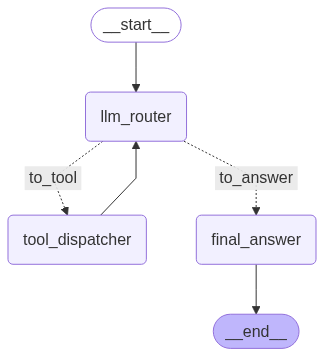

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
def run_bitty(user_text: str, thread_id: str = "demo") -> str:
    state = {
        "messages": [HumanMessage(content=user_text)],
        "tool_calls": [],
        "memory": {},
        "scratchpad": ""
    }
    output = app.invoke(state, config={"configurable": {"thread_id": thread_id}})

    # ✅ Get only the last AIMessage content
    final_output = None
    for msg in reversed(output["messages"]):
        if isinstance(msg, AIMessage):
            final_output = msg
            break

    print(final_output.content) if final_output else print("⚠️ No response")
    
    original_string = final_output.content
    specific_word = "argument"

    # for word in specific_word.items():
    index = original_string.find(specific_word)

    if index != -1:
    #     # Calculate the starting index of the remaining part
    #     # This is the index of the word plus its length
        start_of_remaining = index + len(specific_word)

    #     # Extract the substring from that point onwards
        remaining_string = original_string[start_of_remaining:].strip()

    #     # Print the remaining par
    else:
        print(f"The word '{specific_word}' was not found in the string.")
    print(remaining_string)    
    
    


This Block Takes input in form of voice

In [28]:
import speech_recognition as sr


def listen_command(prompt="Listening...", timeout=5, phrase_time_limit=5):
    """Helper to listen once and return recognized text"""
    recognizer = sr.Recognizer()
    mic = sr.Microphone()

    with mic as source:
        recognizer.adjust_for_ambient_noise(source)
        print(prompt)
        try:
            audio = recognizer.listen(source, timeout=timeout, phrase_time_limit=phrase_time_limit)
            text = recognizer.recognize_google(audio)
            print("Heard:", text)
            return text.lower()
        except sr.UnknownValueError:
            print("Could not understand audio")
            return ""
        except sr.RequestError:
            print("Error: check your internet connection.")
            return ""
        except sr.WaitTimeoutError:
            print("Error: Wait Time Out Error Occured")
            return ""

This Block ensures Awake Word, TineOut, and Functions to run smoothly 

In [29]:
import time, sys
def listen_for_wake_word(wake_word="wake up", active_timeout=15):
    """Wake word once → stay active for commands → sleep after timeout"""
    active_mode = False
    last_command_time = 0

    while True:
        if not active_mode:
            # Waiting for wake word
            speak(f"Bitty Started. Proceed to Activate:  '{wake_word}'...")
            text = listen_command(f"Bitty Started. Proceed to Activate:  '{wake_word}'...")
            if wake_word in text:
                speak("          Bolo Ustad G")
                active_mode = True
                last_command_time = time.time()
        else:
            # Already awake, listen for commands
            while True:
                command = listen_command("Listening for your command...")
                
                last_command_time = time.time()
                print(command)
                checking = run_bitty(command)
                if checking != "repeat" or checking != "exit":
                    print("yes coming")
                    sys.exit("Exiting as User asked")
            

            else:
                
                # No command heard: check if timeout expired
                if time.time() - last_command_time > active_timeout:
                    print("Going back to sleep, say Alexa to wake me up again")
                    speak("Going back to sleep, say Alexa to wake me up again.")
                    break
                    active_mode = False


This __name__ thing lets you run code only if its executed in main file

In [30]:
if __name__ == "__main__":
    listen_for_wake_word("wake up")

KeyboardInterrupt: 